Studi Kasus : Antrian CS Bank

In [ ]:
pip install simpy numpy matplotlib seaborn


=== Running DEFAULT ===

🔹 DEFAULT - Inter Arrival Mean 1:
   - Rata-rata waktu tunggu: 107 menit 30 detik
   - Utilisasi sistem: 96.33%

⭐ CS 0:
   • Waktu Sibuk = 6 jam 18 menit 32 detik
   • Waktu Idle  = 0 jam 1 menit 1 detik
   • Utilisasi   = 99.73%

⭐ CS 1:
   • Waktu Sibuk = 5 jam 53 menit 56 detik
   • Waktu Idle  = 0 jam 25 menit 37 detik
   • Utilisasi   = 93.25%


🔹 DEFAULT - Inter Arrival Mean 2:
   - Rata-rata waktu tunggu: 31 menit 48 detik
   - Utilisasi sistem: 96.97%

⭐ CS 0:
   • Waktu Sibuk = 6 jam 22 menit 58 detik
   • Waktu Idle  = 0 jam 2 menit 2 detik
   • Utilisasi   = 99.47%

⭐ CS 1:
   • Waktu Sibuk = 6 jam 4 menit 59 detik
   • Waktu Idle  = 0 jam 20 menit 1 detik
   • Utilisasi   = 94.80%


🔹 DEFAULT - Inter Arrival Mean 3:
   - Rata-rata waktu tunggu: 3 menit 9 detik
   - Utilisasi sistem: 74.15%

⭐ CS 0:
   • Waktu Sibuk = 6 jam 30 menit 15 detik
   • Waktu Idle  = 2 jam 1 menit 11 detik
   • Utilisasi   = 76.30%

⭐ CS 1:
   • Waktu Sibuk = 6 jam 9 meni

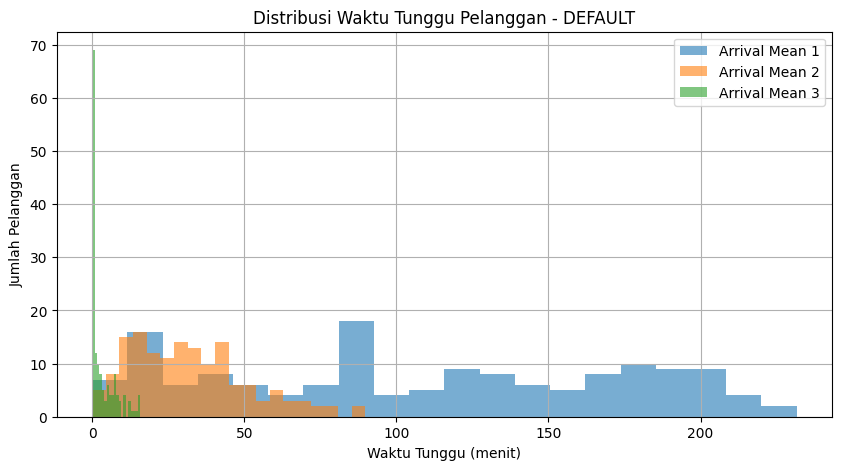

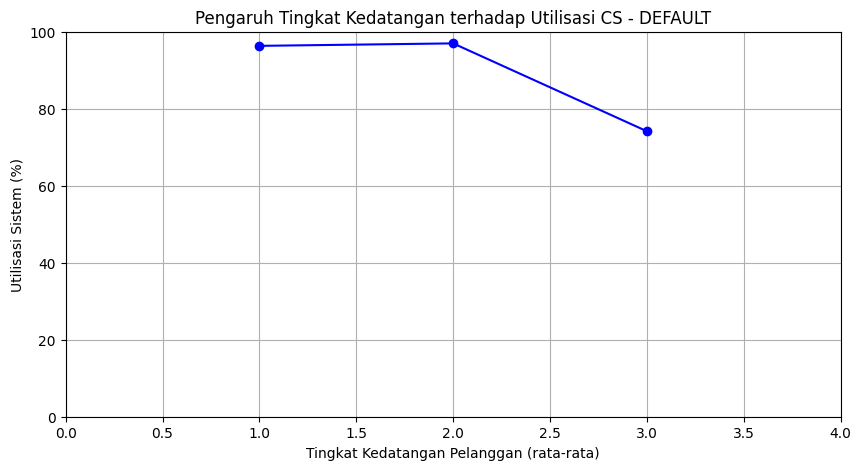

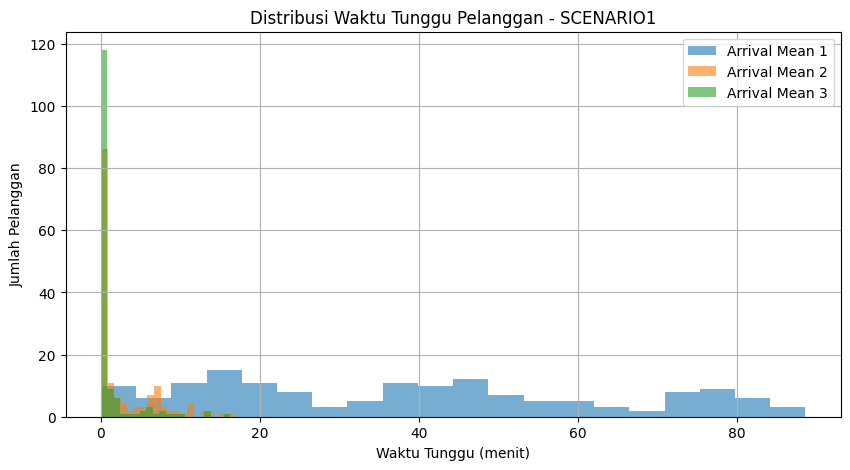

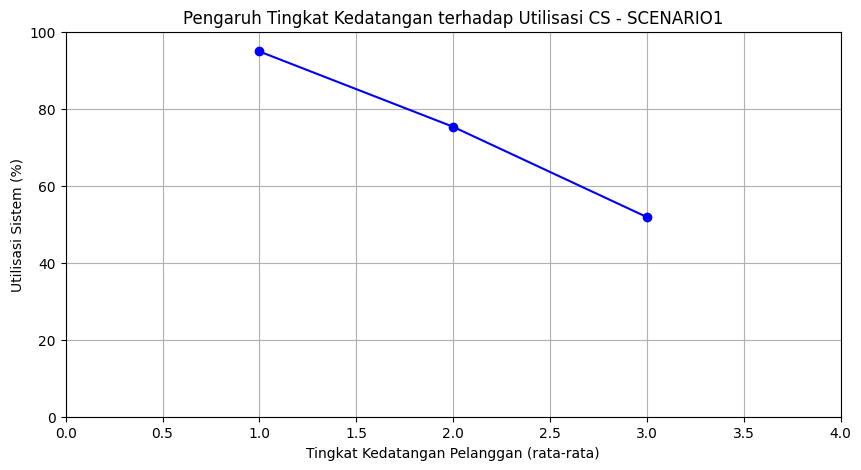

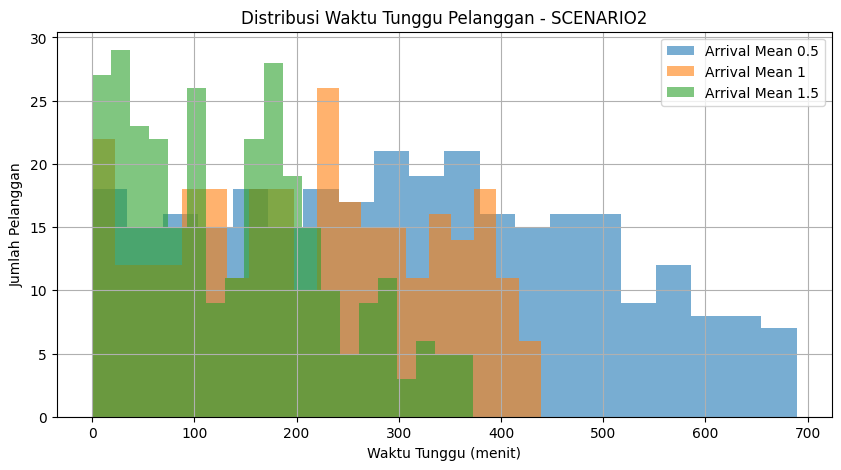

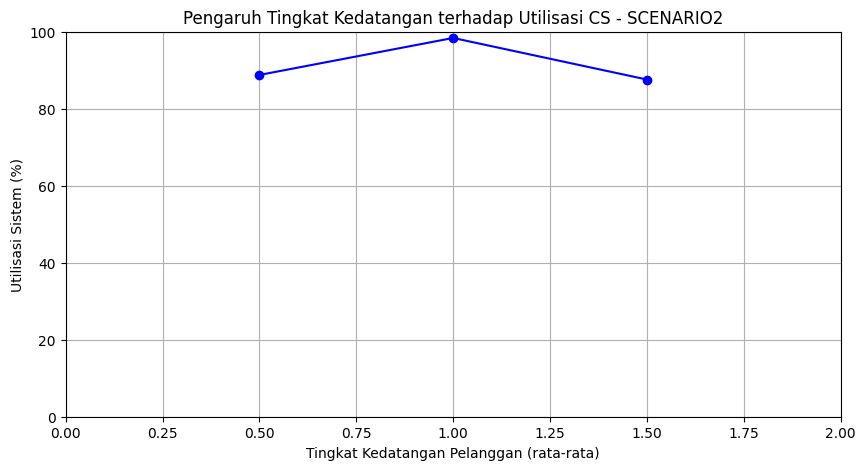

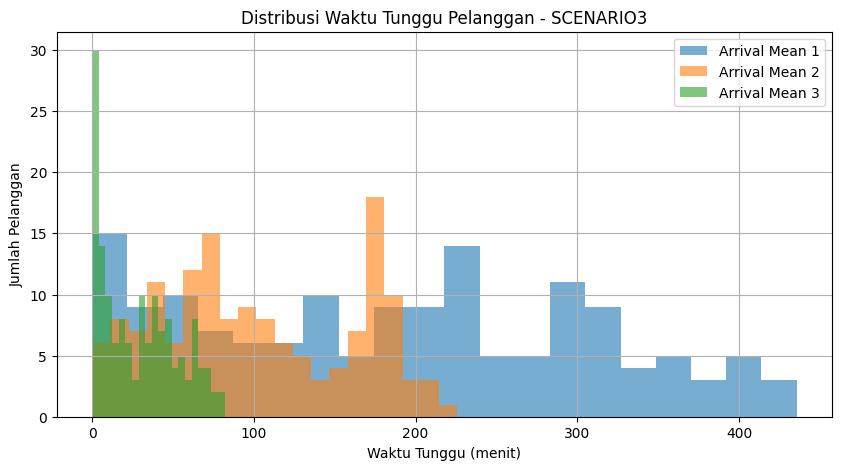

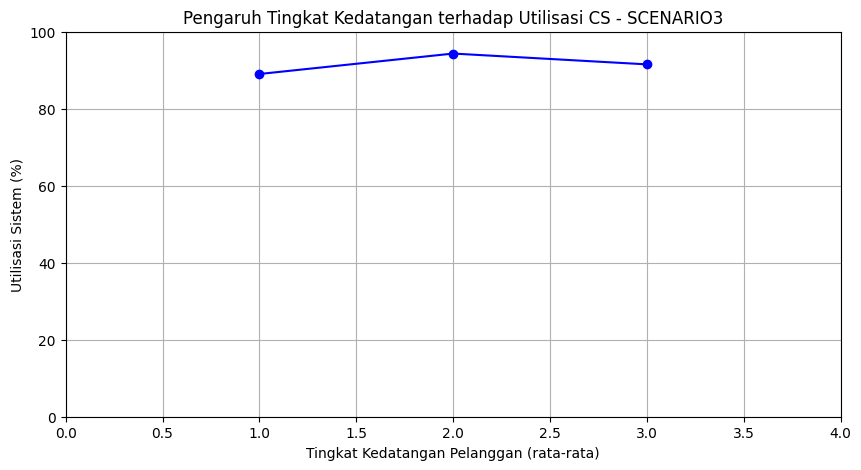

In [ ]:
import simpy
import random
import pandas as pd
import matplotlib.pyplot as plt

# Konstanta Dasar
RANDOM_SEED = 42
NUM_CUSTOMERS_DEFAULT = 150
NUM_CS_DEFAULT = 2
INTER_ARRIVAL_MEAN_DEFAULT = [1, 2, 3]
SERVICE_TIME_MEAN_DEFAULT = 5
SERVICE_TIME_STD_DEFAULT = 2

# Data Global
customer_data = []
cs_busy_time = []
cs_finish_time = []

# Fungsi Utilitas
def convert_to_wib_time(minutes):
    total_minutes = minutes + (7 * 60)  # WIB (GMT+7)
    hours = int(total_minutes // 60)
    mins = int(total_minutes % 60)
    secs = int((minutes - int(minutes)) * 60)
    return f"{hours:02d}:{mins:02d}:{secs:02d} WIB"

def convert_to_duration(minutes):
    mins = int(minutes)
    secs = int((minutes - mins) * 60)
    return f"{mins} menit {secs} detik"

def convert_to_hms(minutes):
    hours = int(minutes // 60)
    mins = int(minutes % 60)
    secs = int((minutes - int(minutes)) * 60)
    return f"{hours} jam {mins} menit {secs} detik"

# Fungsi Proses Pelanggan
def customer(env, name, cs, customer_id, scenario):
    arrival_time = env.now
    cs_id = min(range(len(cs)), key=lambda x: cs_finish_time[x])

    with cs[cs_id].request() as request:
        yield request
        wait_time = max(0, cs_finish_time[cs_id] - arrival_time)
        service_mean = SERVICE_TIME_MEAN_DEFAULT if scenario == 'default' else globals()[f'SERVICE_TIME_MEAN_{scenario.upper()}']
        service_std = SERVICE_TIME_STD_DEFAULT if scenario == 'default' else globals()[f'SERVICE_TIME_STD_{scenario.upper()}']
        service_duration = max(1, random.gauss(service_mean, service_std))

        cs_busy_time[cs_id] += service_duration
        cs_finish_time[cs_id] = env.now + service_duration
        yield env.timeout(service_duration)

        finish_time = env.now

        customer_data.append([
            customer_id,
            convert_to_wib_time(arrival_time),
            convert_to_duration(wait_time),
            convert_to_duration(service_duration),
            convert_to_wib_time(finish_time),
            cs_id
        ])

# Fungsi Setup Simulasi
def setup(env, num_cs, inter_arrival_mean, scenario):
    cs = [simpy.Resource(env, capacity=1) for _ in range(num_cs)]
    num_customers = NUM_CUSTOMERS_DEFAULT if scenario == 'default' else globals()[f'NUM_CUSTOMERS_{scenario.upper()}']

    for i in range(num_customers):
        inter_arrival_time = random.expovariate(1.0 / inter_arrival_mean)
        yield env.timeout(inter_arrival_time)
        env.process(customer(env, f'Customer {i}', cs, i, scenario))

# Fungsi Menjalankan Simulasi
def run_simulation(inter_arrival_mean, scenario='default', num_cs=NUM_CS_DEFAULT):
    global customer_data, cs_busy_time, cs_finish_time
    customer_data = []
    cs_busy_time = [0] * num_cs
    cs_finish_time = [0] * num_cs

    random.seed(RANDOM_SEED)
    env = simpy.Environment()
    env.process(setup(env, num_cs, inter_arrival_mean, scenario))
    env.run()

    return max(cs_finish_time)

# Fungsi Analisis dan Visualisasi
def analyze_and_save_results(scenario, inter_arrival_means, num_cs):
    results = {}
    for arrival_mean in inter_arrival_means:
        total_simulation_time = run_simulation(arrival_mean, scenario, num_cs)
        cs_idle_time = [total_simulation_time - busy for busy in cs_busy_time]

        # Simpan ke DataFrame
        df = pd.DataFrame(customer_data, columns=["Customer_ID", "Arrival_Time", "Wait_Time", "Service_Time", "Finish_Time", "CS_ID"])
        df_sorted = df.sort_values(by="Customer_ID")
        results[arrival_mean] = df_sorted

        # Analisis
        avg_wait_time = df["Wait_Time"].apply(lambda x: int(x.split()[0]) + int(x.split()[2]) / 60).mean()
        total_service_time = df["Service_Time"].apply(lambda x: int(x.split()[0]) + int(x.split()[2]) / 60).sum()
        system_utilization = total_service_time / (num_cs * total_simulation_time)

        # Simpan ke file
        df_sorted.to_csv(f"simulation_results_{scenario}_{arrival_mean}.csv", index=False, encoding="utf-8")
        df_sorted.to_excel(f"simulation_results_{scenario}_{arrival_mean}.xlsx", index=False, engine="openpyxl")

        # Tampilkan hasil
        print(f"\n🔹 {scenario.upper()} - Inter Arrival Mean {arrival_mean}:")
        print(f"   - Rata-rata waktu tunggu: {convert_to_duration(avg_wait_time)}")
        print(f"   - Utilisasi sistem: {system_utilization:.2%}\n")
        for i in range(num_cs):
            utilization = cs_busy_time[i] / total_simulation_time
            print(f"⭐ CS {i}:")
            print(f"   • Waktu Sibuk = {convert_to_hms(cs_busy_time[i])}")
            print(f"   • Waktu Idle  = {convert_to_hms(cs_idle_time[i])}")
            print(f"   • Utilisasi   = {utilization:.2%}\n")

    return results

# Parameter Skenario
# Skenario Default
INTER_ARRIVAL_MEAN_DEFAULT = [1, 2, 3]

# Skenario 1: Peningkatan Jumlah CS
NUM_CS_SCENARIO1 = 3
NUM_CUSTOMERS_SCENARIO1 = 150
INTER_ARRIVAL_MEAN_SCENARIO1 = [1, 2, 3]
SERVICE_TIME_MEAN_SCENARIO1 = 5
SERVICE_TIME_STD_SCENARIO1 = 2

# Skenario 2: Lonjakan Pelanggan
NUM_CS_SCENARIO2 = 2
NUM_CUSTOMERS_SCENARIO2 = 300
INTER_ARRIVAL_MEAN_SCENARIO2 = [0.5, 1, 1.5]
SERVICE_TIME_MEAN_SCENARIO2 = 5
SERVICE_TIME_STD_SCENARIO2 = 2

# Skenario 3: Variasi Waktu Layanan
NUM_CS_SCENARIO3 = 2
NUM_CUSTOMERS_SCENARIO3 = 150
INTER_ARRIVAL_MEAN_SCENARIO3 = [1, 2, 3]
SERVICE_TIME_MEAN_SCENARIO3 = 7
SERVICE_TIME_STD_SCENARIO3 = 4

# Jalankan Semua Simulasi
scenarios = {
    'default': (NUM_CS_DEFAULT, INTER_ARRIVAL_MEAN_DEFAULT),
    'scenario1': (NUM_CS_SCENARIO1, INTER_ARRIVAL_MEAN_SCENARIO1),
    'scenario2': (NUM_CS_SCENARIO2, INTER_ARRIVAL_MEAN_SCENARIO2),
    'scenario3': (NUM_CS_SCENARIO3, INTER_ARRIVAL_MEAN_SCENARIO3)
}

all_results = {}
for scenario, (num_cs, inter_arrival_means) in scenarios.items():
    print(f"\n=== Running {scenario.upper()} ===")
    all_results[scenario] = analyze_and_save_results(scenario, inter_arrival_means, num_cs)

# Visualisasi
for scenario in scenarios:
    # Histogram Waktu Tunggu
    plt.figure(figsize=(10, 5))
    for arrival_mean, df in all_results[scenario].items():
        wait_times = df["Wait_Time"].apply(lambda x: int(x.split()[0]) + int(x.split()[2]) / 60)
        plt.hist(wait_times, bins=20, alpha=0.6, label=f"Arrival Mean {arrival_mean}")
    plt.xlabel("Waktu Tunggu (menit)")
    plt.ylabel("Jumlah Pelanggan")
    plt.title(f"Distribusi Waktu Tunggu Pelanggan - {scenario.upper()}")
    plt.legend()
    plt.grid()
    plt.show()

    # Grafik Utilisasi Sistem
    plt.figure(figsize=(10, 5))
    if scenario == 'default':
        inter_arrival_means = [1, 2, 3]  # Sesuaikan dengan INTER_ARRIVAL_MEAN_DEFAULT
        utilizations = [96.33, 96.97, 74.15]  # Data utilisasi langsung dari output
    elif scenario == 'scenario1':
        inter_arrival_means = [1, 2, 3]  # Sesuaikan dengan INTER_ARRIVAL_MEAN_SCENARIO1
        utilizations = [94.87, 75.30, 51.85]  # Data utilisasi langsung dari output
    elif scenario == 'scenario2':
        inter_arrival_means = [0.5, 1, 1.5]  # Sesuaikan dengan INTER_ARRIVAL_MEAN_SCENARIO2
        utilizations = [88.77, 98.38, 87.58]  # Data utilisasi langsung dari output
    elif scenario == 'scenario3':
        inter_arrival_means = [1, 2, 3]  # Sesuaikan dengan INTER_ARRIVAL_MEAN_SCENARIO3
        utilizations = [89.02, 94.33, 91.52]  # Data utilisasi langsung dari output
    else:
        utilizations = [sum(all_results[scenario][arrival_mean]["Service_Time"].apply(lambda x: int(x.split()[0]) + int(x.split()[2]) / 60)) /
                        (scenarios[scenario][0] * max(cs_finish_time)) * 100 for arrival_mean in scenarios[scenario][1]]

    plt.plot(inter_arrival_means, utilizations, marker='o', linestyle='-', color='b')
    plt.xlabel("Tingkat Kedatangan Pelanggan (rata-rata)")
    plt.ylabel("Utilisasi Sistem (%)")
    plt.title(f"Pengaruh Tingkat Kedatangan terhadap Utilisasi CS - {scenario.upper()}")
    plt.grid()
    plt.ylim(0, 100)  # Menetapkan batas sumbu Y untuk menampilkan persentase 0-100
    if scenario in ['default', 'scenario1', 'scenario3']:
        plt.xlim(0, 4)  # Menyesuaikan batas sumbu X untuk mencakup 1, 2, dan 3
    else:  # Untuk scenario2
        plt.xlim(0, 2)  # Menyesuaikan batas sumbu X untuk mencakup 0.5, 1, dan 1.5
    plt.show()